In [1]:
# Get raw data
with open('input/13.txt', 'r') as f:
    rawinput = f.read().strip()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Part 1
def do_fold(paper, axis, pos):
    return np.max(np.stack([[j,np.flip(j, axis=axis)][i]
                            for i,j in enumerate(np.split(paper, 
                                                          [pos, pos+1], 
                                                          axis=axis)[::2])]), 
                  axis=0)
    
raw_dots, raw_folds = [i for i in rawinput.split('\n\n')]
dots = [tuple([int(j) for j in i.split(',')][::-1])
        for i in raw_dots.split('\n')]
folds = [(int(i[11]=='x'), int(i[13:])) for i in raw_folds.split('\n')]

paper = np.zeros([max(i)+max(i)%2+1 for i in zip(*dots)], dtype=int)
paper[*zip(*dots)] = 1

np.sum(do_fold(paper, *folds[0])).item()

763

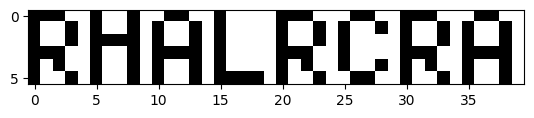

In [4]:
# Part 2
for f in folds:
    paper = do_fold(paper, *f)

plt.imshow(paper, cmap='gray_r')